# 1. 个人信用评分与客户违约识别

## 一、实验简介

本实验围绕 **信贷审批（Credit Risk / Loan Approval）** 场景展开，使用基于树的模型（Decision Tree、Random Forest、XGBoost）对客户进行信贷风险评估，并深入分析**特征重要性（Feature Importance）**，以解释"为什么贷款申请被拒绝"。

**为什么选择树模型做信贷审批？**

在金融行业中，树模型是**表格数据（Tabular Data）上的行业标准**，原因有三：

1. **高性能**：在结构化数据上，集成树模型（Random Forest、XGBoost）通常优于深度学习模型。
2. **可解释性**：金融监管要求模型必须能够解释决策依据。树模型天然支持特征重要性提取，可以回答"为什么拒绝了这笔贷款"。
3. **鲁棒性**：树模型对缺失值、异常值和特征尺度不敏感，在实际生产环境中维护成本低。

本实验使用 **German Credit Data（UCI）** 数据集，通过 scikit-learn 的 OpenML 接口获取。

## 二、实验目标

- 理解决策树的基本原理——**信息增益（Information Gain）** 与 **基尼不纯度（Gini Impurity）**。
- 掌握随机森林如何通过 **Bagging** 和 **特征随机采样** 降低过拟合。
- 理解 XGBoost 如何通过 **梯度提升（Gradient Boosting）** 逐步优化残差。
- 深入理解分类模型的评估指标：**准确率（Accuracy）、精确率（Precision）、召回率（Recall）、F1 值、AUC-ROC**，以及在信贷场景下"什么才是好模型"。
- 掌握特征重要性的提取与可视化方法，学会解释模型决策。

## 三、实验要求

- 使用 OpenML 获取 German Credit 数据集。
- 构建单棵决策树并可视化决策边界（如"收入 > X 且 负债 < Y"）。
- 构建随机森林模型和 XGBoost 模型。
- 对三个模型进行系统性评估与对比。
- 重点提取和可视化特征重要性，解释贷款被拒的原因。

## 四、思考提示

1. 决策树的"深度"对模型性能有什么影响？过深和过浅各有什么问题？
2. 随机森林为什么能比单棵决策树表现更好？它的"随机"体现在哪里？
3. XGBoost 相比随机森林的核心优势是什么？
4. 在信贷审批场景中，Precision 和 Recall 哪个更重要？为什么？
5. 如果一个模型准确率很高但 AUC 很低，可能是什么原因？

---

## 1. 环境准备

In [16]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# XGBoost
# Ref: https://xgboost.readthedocs.io/
import xgboost as xgb
from matplotlib import font_manager
# scikit-learn 相关
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")

接下来配置中文字体，确保图表中的中文标签能正确显示：

In [17]:
def configure_plot_fonts() -> None:
    """配置 matplotlib 中文字体，避免 seaborn 主题覆盖字体设置。"""
    sns.set_theme(style="whitegrid")
    font_candidates = [
        "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
        "PingFang SC", "WenQuanYi Zen Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next(
        (name for name in font_candidates if name in available_fonts), None
    )
    if selected_font is None:
        warnings.warn(
            "未检测到常见中文字体，图表中文可能显示为方块。"
            "建议安装 'Microsoft YaHei' 或 'Noto Sans CJK SC'。",
            UserWarning,
        )
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    else:
        plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()

---

## 2. 数据集加载与预处理

### 2.1 使用 OpenML 获取 German Credit 数据

我们通过 scikit-learn 的 `fetch_openml` 接口获取 German Credit 数据集（OpenML ID: 31）。这个数据集包含 1000 条记录，每条记录描述一个贷款申请人的各项特征，目标变量为"好信用（good）"或"坏信用（bad）"。

**为什么使用 `fetch_openml`？** 因为它能自动从 OpenML 平台下载标准化的机器学习数据集，避免了手动下载和清洗的繁琐步骤，非常适合教学环境。

In [18]:
# Ref: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
# 获取 German Credit 数据集（OpenML dataset id=31）
credit_data = fetch_openml(data_id=31, as_frame=True, parser="auto")

df = credit_data.frame
target_col = credit_data.target_names[0] if credit_data.target_names else "class"

print(f"数据集维度：{df.shape}")
print(f"目标变量：{target_col}")
print(f"目标变量分布：\n{df[target_col].value_counts()}")

数据集维度：(1000, 21)
目标变量：class
目标变量分布：
class
good    700
bad     300
Name: count, dtype: int64


### 2.2 数据预处理

German Credit 数据集中包含多个分类特征（category 类型）。树模型虽然理论上可以处理分类变量，但 scikit-learn 的实现要求输入为数值类型。因此我们需要对分类特征进行 **标签编码（Label Encoding）**。

**为什么用 Label Encoding 而不是 One-Hot Encoding？** 对于树模型，Label Encoding 通常就足够了，因为树模型通过分裂点（threshold）来划分数据，不会像线性模型那样受到编码数值大小的影响。而 One-Hot Encoding 会大幅增加特征维度，反而可能降低树模型的效率。

In [19]:
# 分离特征和目标变量
X = df.drop(columns=[target_col])
y = df[target_col]

# 将目标变量编码为 0/1（good=1, bad=0）
# 在信贷场景中，我们通常关注"谁会违约"，因此将 "bad" 编码为 1（正类）
# 这样 Recall 衡量的就是"在真正违约的人中，我们识别出了多少"
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
# 确认编码映射
print(f"目标编码映射：{dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# 对分类特征进行 Label Encoding
label_encoders = {}
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=["category", "object"]).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print(f"\n编码后特征矩阵维度：{X_encoded.shape}")
print(f"编码后前 5 行：")
display(X_encoded.head())

目标编码映射：{'bad': np.int64(0), 'good': np.int64(1)}

编码后特征矩阵维度：(1000, 20)
编码后前 5 行：


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,1,6,1,6,1169,4,3,4,3,2,4,3,67,1,1,2,1,1,1,1
1,0,48,3,6,5951,2,0,2,0,2,2,3,22,1,1,1,1,1,0,1
2,3,12,1,2,2096,2,1,2,3,2,3,3,49,1,1,1,3,2,0,1
3,1,42,3,3,7882,2,1,2,3,1,4,1,45,1,0,1,1,2,0,1
4,1,24,2,4,4870,2,0,3,3,2,4,2,53,1,0,2,1,2,0,1


### 2.3 划分训练集与测试集

In [20]:
# 使用 80/20 划分，stratify 保证训练集和测试集中正负样本比例一致
# 这在不平衡数据集中尤为重要
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded,
)

print(f"训练集大小：{X_train.shape[0]}")
print(f"测试集大小：{X_test.shape[0]}")
print(f"训练集正类比例：{y_train.mean():.3f}")
print(f"测试集正类比例：{y_test.mean():.3f}")

训练集大小：800
测试集大小：200
训练集正类比例：0.700
测试集正类比例：0.700


---

## 3. 核心概念

### 3.1 决策树（Decision Tree）

决策树通过递归地选择**最优分裂特征和分裂点**来构建一棵树。每个内部节点代表一个"判断条件"（如"收入 > 50000"），每个叶子节点代表一个分类结果。

**分裂准则**有两种常用方式：
- **基尼不纯度（Gini Impurity）**：衡量一个节点中样本的"混乱程度"。Gini = 0 表示纯净（只有一类），Gini 越大越混乱。
- **信息增益（Information Gain / Entropy）**：基于信息论，选择能最大程度降低不确定性的特征进行分裂。

**决策树的优缺点**：
- ✅ 可解释性极强：可以直观展示"如果...则..."的决策路径。
- ✅ 不需要特征缩放。
- ❌ 容易过拟合：树越深，越容易"记住"训练数据中的噪声。
- ❌ 不稳定：数据微小变化可能导致完全不同的树结构。

### 3.2 随机森林（Random Forest）

随机森林通过 **Bagging（Bootstrap Aggregating）** 策略，训练多棵决策树并取它们的"投票结果"。

**"随机"体现在两个层面**：
1. **样本随机**：每棵树使用 Bootstrap 采样（有放回抽样）生成的子数据集训练。
2. **特征随机**：每次分裂时，只从随机选择的特征子集中选取最优分裂特征。

这种"双重随机性"使得各棵树之间尽可能不同，从而在集成时有效降低方差（过拟合）。

### 3.3 XGBoost

XGBoost（eXtreme Gradient Boosting）是 **梯度提升（Gradient Boosting）** 的高效实现。与随机森林的"并行投票"不同，XGBoost 采用 **串行策略**：每一棵新树都在拟合前一棵树的"残差（错误）"。

**核心思想**：不断修正前一轮模型犯的错误，逐步逼近完美预测。

**XGBoost 的优势**：
- 支持正则化（L1/L2），防止过拟合。
- 内置处理缺失值的机制。
- 支持并行计算，训练速度快。
- 在 Kaggle 等竞赛中屡屡获奖，是结构化数据上的"冠军算法"。

### 3.4 评估指标详解

在信贷审批场景中，不同的评估指标有不同的业务含义：

| 指标 | 公式 | 业务含义 |
|------|------|----------|
| **Accuracy（准确率）** | (TP+TN)/(TP+TN+FP+FN) | 整体预测正确的比例。**在不平衡数据中可能具有误导性**。 |
| **Precision（精确率）** | TP/(TP+FP) | "模型预测为违约的人中，真正违约的比例"。高 Precision 意味着少误杀好客户。 |
| **Recall（召回率）** | TP/(TP+FN) | "真正违约的人中，被模型识别出的比例"。高 Recall 意味着少漏掉坏客户。 |
| **F1 Score** | 2×Precision×Recall/(Precision+Recall) | Precision 和 Recall 的调和平均，综合衡量模型性能。 |
| **AUC-ROC** | ROC 曲线下面积 | 衡量模型区分正负样本的综合能力，不受分类阈值影响。**AUC = 0.5 等于随机猜测，AUC = 1.0 是完美分类。** |

> **在信贷场景中，Recall 通常比 Precision 更重要**——因为漏掉一个真正的违约客户（假阴性）造成的损失远大于误拒一个好客户（假阳性）。

---

## 4. 构建决策树模型

### 4.1 训练决策树

我们首先训练一棵**浅层决策树**（max_depth=4），这样可以方便地可视化决策过程。

**为什么限制深度？** 不限制深度的决策树会过拟合训练数据——它会"记住"每一个训练样本的特征，导致在新数据上表现很差。限制深度是最简单的正则化手段。

In [21]:
# 训练决策树，限制最大深度为 4 以便可视化
dt_clf = DecisionTreeClassifier(
    max_depth=4,           # 限制树的深度，防止过拟合
    criterion="gini",      # 使用基尼不纯度作为分裂准则
    random_state=42,
    class_weight="balanced",  # 处理类别不平衡：自动调整各类的权重
)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

print("=== 决策树模型评估 ===")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_dt):.4f}")

=== 决策树模型评估 ===
              precision    recall  f1-score   support

         bad       0.40      0.78      0.53        60
        good       0.84      0.49      0.62       140

    accuracy                           0.58       200
   macro avg       0.62      0.64      0.57       200
weighted avg       0.71      0.58      0.59       200

AUC-ROC: 0.6936


### 4.2 可视化决策树

决策树最大的优势就是**可解释性**。我们可以直接"看到"模型是如何做决策的：

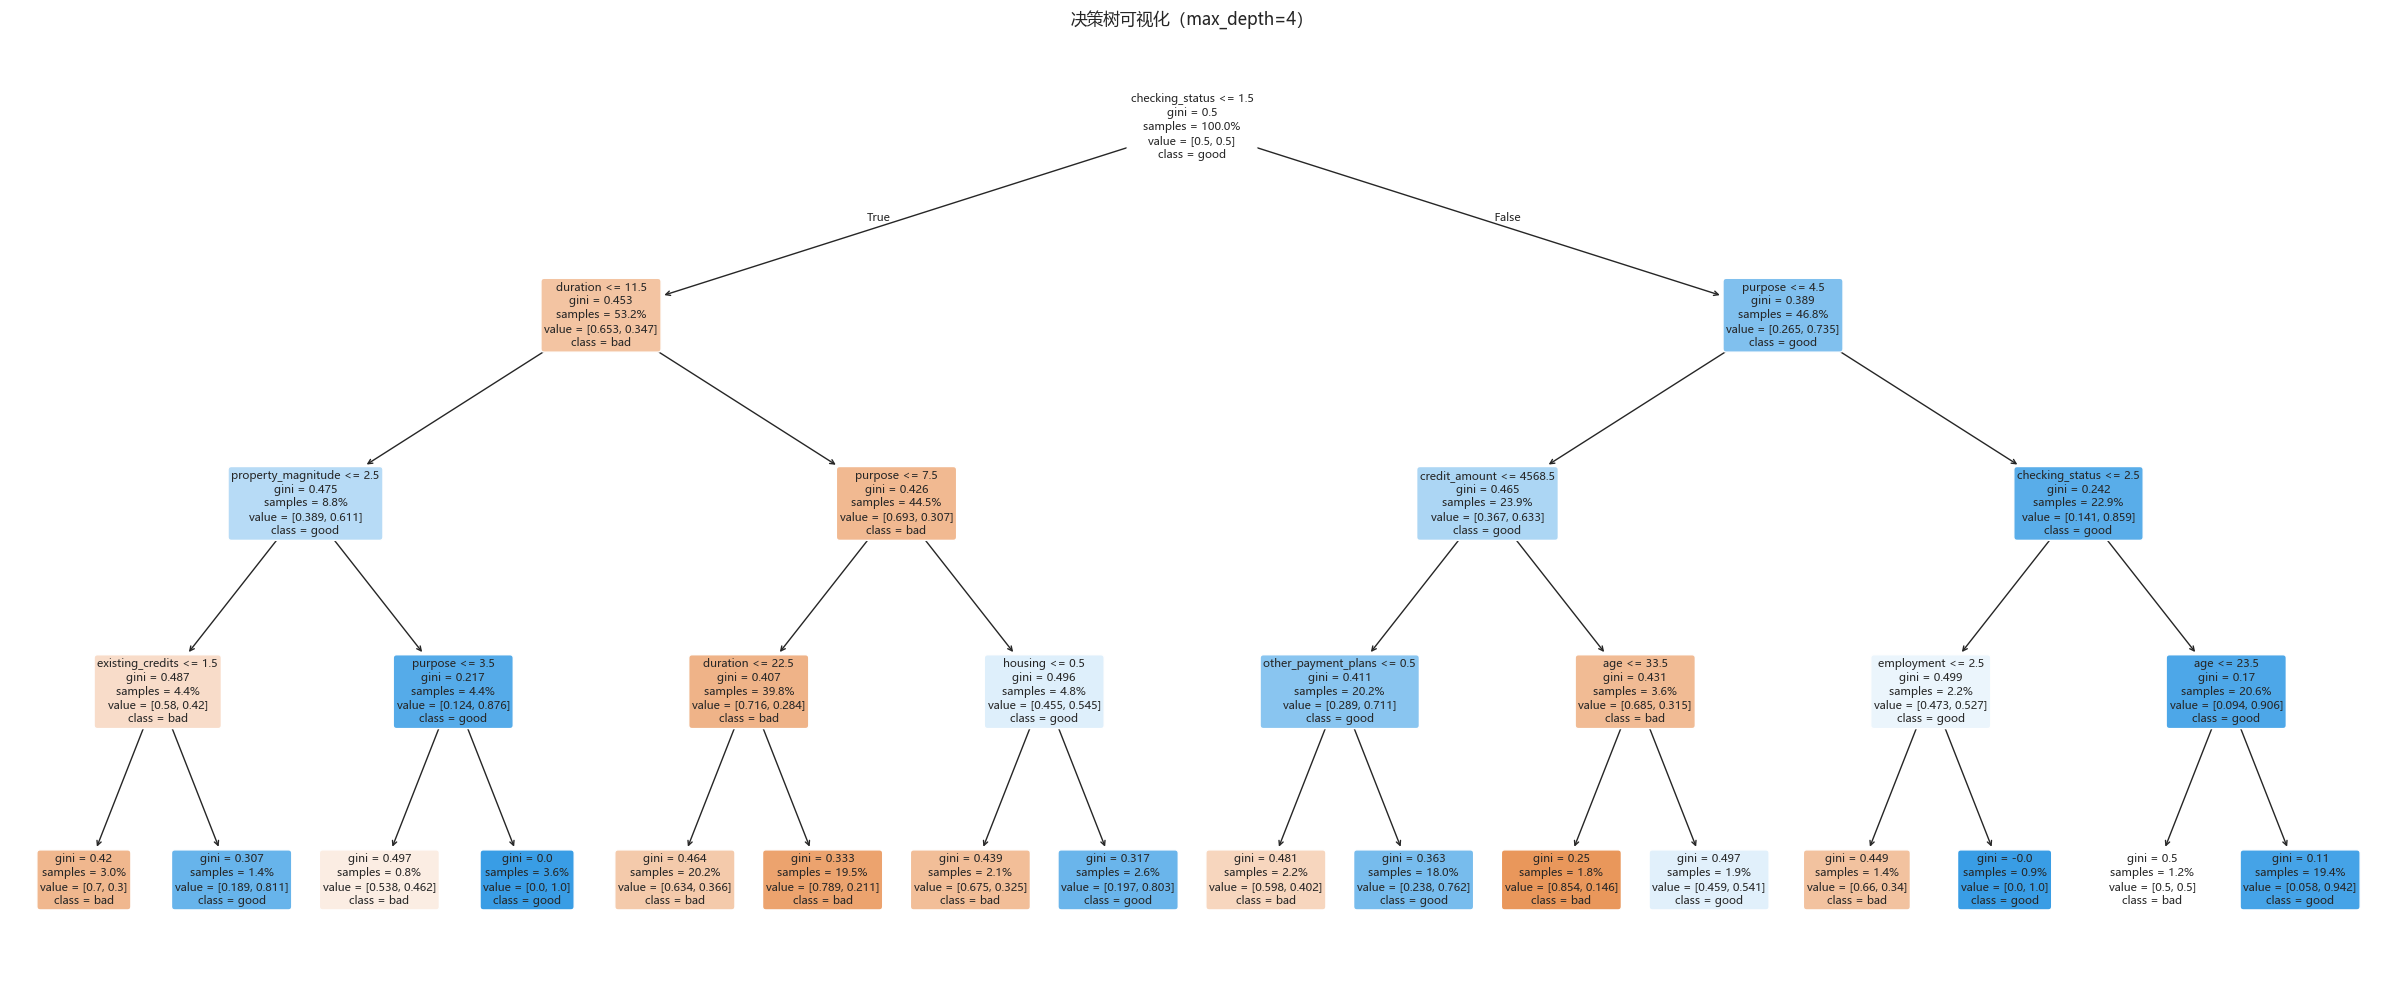

In [22]:
plt.figure(figsize=(24, 10))
plot_tree(
    dt_clf,
    feature_names=X_encoded.columns.tolist(),
    class_names=le_target.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
)
plt.title("决策树可视化（max_depth=4）")
plt.tight_layout()
plt.show()

> **如何阅读决策树**：从根节点开始，每个节点显示分裂条件（如"checking_status <= 1.5"）、基尼不纯度、样本比例和预测类别。左分支为"条件成立"，右分支为"条件不成立"。叶子节点的颜色深浅代表分类的确信程度。

---

## 5. 构建随机森林模型

### 5.1 训练随机森林

In [23]:
# 训练随机森林
# n_estimators：森林中树的数量。越多越好，但计算成本也越高。
# max_depth：每棵树的最大深度。限制深度可以防止过拟合。
# max_features：每次分裂时考虑的特征数量。"sqrt" 表示取特征总数的平方根。
# class_weight："balanced" 自动根据类别频率调整权重，处理不平衡数据。
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    max_features="sqrt",
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,  # 使用所有 CPU 核心并行训练
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print("=== 随机森林模型评估 ===")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== 随机森林模型评估 ===
              precision    recall  f1-score   support

         bad       0.52      0.55      0.54        60
        good       0.80      0.79      0.79       140

    accuracy                           0.71       200
   macro avg       0.66      0.67      0.67       200
weighted avg       0.72      0.71      0.72       200

AUC-ROC: 0.7690


---

## 6. 构建 XGBoost 模型

### 6.1 训练 XGBoost

In [24]:
# 计算正负样本比例，用于 scale_pos_weight 参数
# 这个参数告诉 XGBoost "正样本（违约）应该被赋予多大的权重"
# 在不平衡数据中非常重要
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count

print(f"负类数量：{neg_count}, 正类数量：{pos_count}, 比例：{scale_ratio:.2f}")

# Ref: https://xgboost.readthedocs.io/en/stable/parameter.html
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,        # 学习率：每棵树的贡献权重。越小越保守，需要更多树。
    scale_pos_weight=scale_ratio,  # 处理类别不平衡
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("=== XGBoost 模型评估 ===")
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

负类数量：240, 正类数量：560, 比例：0.43
=== XGBoost 模型评估 ===
              precision    recall  f1-score   support

         bad       0.50      0.57      0.53        60
        good       0.80      0.76      0.78       140

    accuracy                           0.70       200
   macro avg       0.65      0.66      0.66       200
weighted avg       0.71      0.70      0.70       200

AUC-ROC: 0.7524


---

## 7. 模型对比与评估

### 7.1 三模型 ROC 曲线对比

ROC 曲线展示了在不同分类阈值下，模型的 **真正率（Recall）** 与 **假正率（FPR）** 之间的权衡关系。曲线越靠近左上角，模型越好。

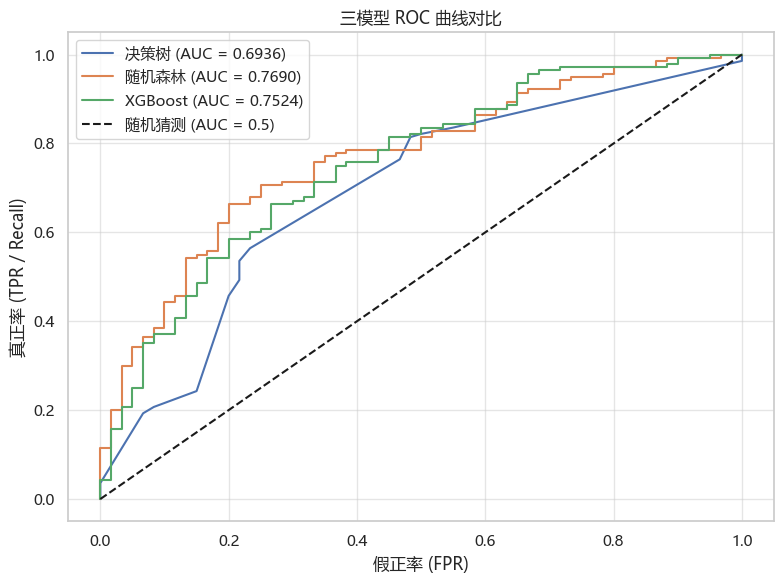

In [25]:
plt.figure(figsize=(8, 6))

for name, y_prob in [
    ("决策树", y_prob_dt),
    ("随机森林", y_prob_rf),
    ("XGBoost", y_prob_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="随机猜测 (AUC = 0.5)")
plt.xlabel("假正率 (FPR)")
plt.ylabel("真正率 (TPR / Recall)")
plt.title("三模型 ROC 曲线对比")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 评估指标汇总

In [26]:
results = []
for name, y_pred, y_prob in [
    ("决策树", y_pred_dt, y_prob_dt),
    ("随机森林", y_pred_rf, y_prob_rf),
    ("XGBoost", y_pred_xgb, y_prob_xgb),
]:
    results.append({
        "模型": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results)
print("\n=== 三模型评估指标汇总 ===")
display(results_df)


=== 三模型评估指标汇总 ===


,模型,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,决策树,0.580,0.8415,0.4929,0.6216,0.6936
1,随机森林,0.715,0.8029,0.7857,0.7942,0.7690
2,XGBoost,0.700,0.8030,0.7571,0.7794,0.7524


> **如何判断哪个模型最好？** 不能只看 Accuracy。在信贷场景中，应重点关注：
> 1. **AUC-ROC**：衡量模型的综合区分能力，不受阈值影响。
> 2. **Recall**：尽量识别出所有违约客户。
> 3. **F1 Score**：在 Precision 和 Recall 之间的平衡。

---

## 8. 特征重要性分析

### 8.1 为什么特征重要性如此重要？

在信贷审批中，监管机构要求银行必须能够**解释为什么拒绝了一笔贷款申请**。这就是特征重要性分析的价值所在：

- 它告诉我们**哪些因素对贷款审批结果影响最大**。
- 例如，如果"checking_status（支票账户状态）"是最重要的特征，说明银行最看重申请人的流动资金状况。
- 这种解释性是树模型在金融行业被广泛采用的核心原因。

### 8.2 提取三个模型的特征重要性

In [27]:
feature_names = X_encoded.columns.tolist()

# 决策树特征重要性
dt_importance = pd.Series(dt_clf.feature_importances_, index=feature_names)

# 随机森林特征重要性
rf_importance = pd.Series(rf_clf.feature_importances_, index=feature_names)

# XGBoost 特征重要性
xgb_importance = pd.Series(xgb_clf.feature_importances_, index=feature_names)

### 8.3 可视化 Top 10 特征重要性

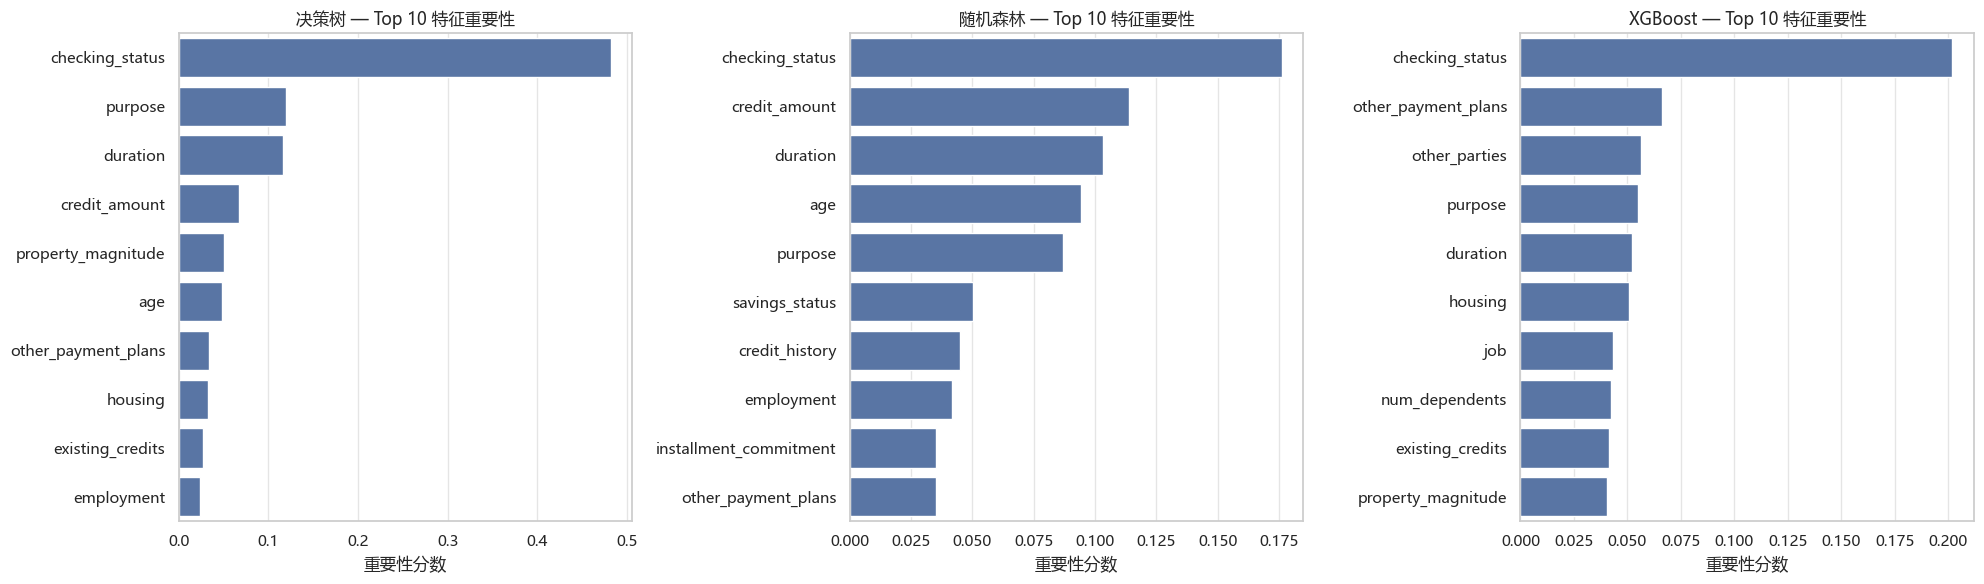

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, importance, name in [
    (axes[0], dt_importance, "决策树"),
    (axes[1], rf_importance, "随机森林"),
    (axes[2], xgb_importance, "XGBoost"),
]:
    top10 = importance.sort_values(ascending=False).head(10)
    sns.barplot(x=top10.values, y=top10.index, ax=ax)
    ax.set_title(f"{name} — Top 10 特征重要性")
    ax.set_xlabel("重要性分数")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 8.4 特征重要性的业务解读

观察上面的图表，思考以下问题：

- **哪些特征在三个模型中都排名靠前？** 这些特征是最稳健的"信贷风险指标"。
- **不同模型的特征重要性排序是否一致？** 如果不一致，说明模型捕捉了数据的不同方面。
- **如何用这些结果向客户解释"为什么贷款被拒绝"？** 例如："您的支票账户余额较低（checking_status），贷款期限较长（duration），且贷款金额较高（credit_amount），这些因素综合导致您的信贷风险评分较高。"

---

## 9. 混淆矩阵对比

混淆矩阵直观展示了模型在四个维度上的表现：真正例（TP）、真负例（TN）、假正例（FP）、假负例（FN）。

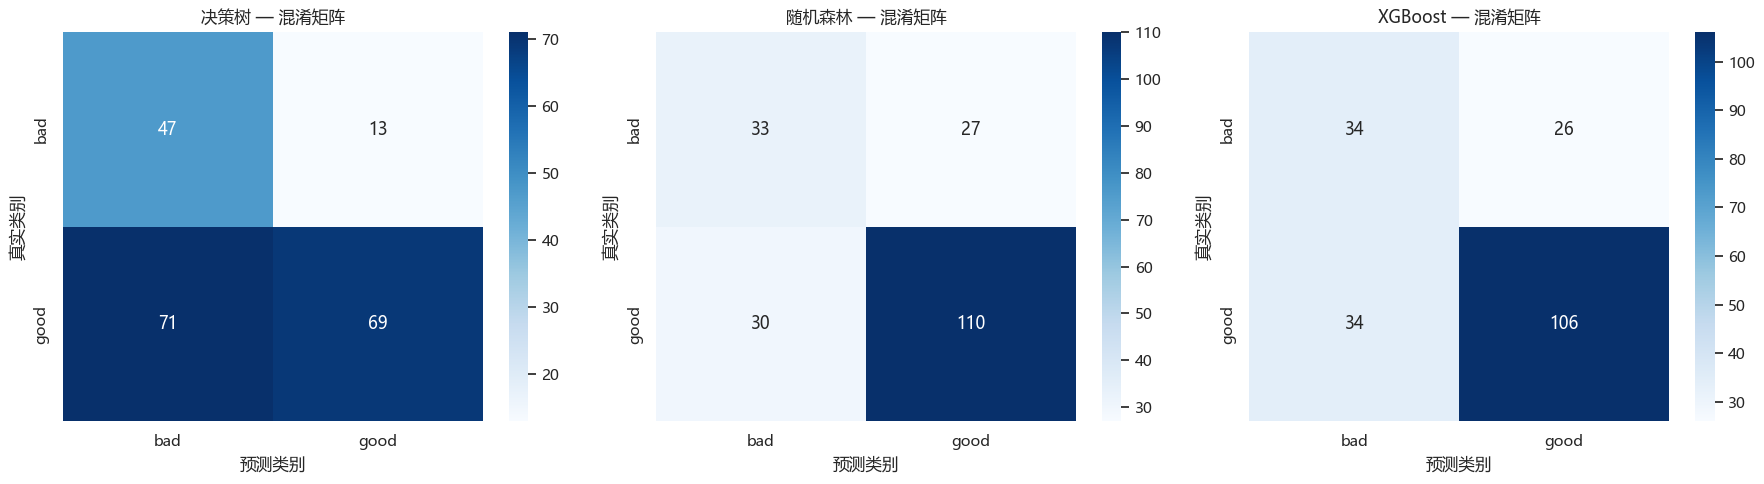

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, name in [
    (axes[0], y_pred_dt, "决策树"),
    (axes[1], y_pred_rf, "随机森林"),
    (axes[2], y_pred_xgb, "XGBoost"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    ax.set_title(f"{name} — 混淆矩阵")
    ax.set_xlabel("预测类别")
    ax.set_ylabel("真实类别")

plt.tight_layout()
plt.show()

> **阅读混淆矩阵**：在信贷场景中，右上角的 FN（假阴性：真正违约但被模型判为好客户）是最危险的，因为银行会因此蒙受损失。好模型应该尽量减少 FN 的数量。

---

## 10. 实验结论

### 10.1 什么是好模型？

在信贷审批场景中，"好模型"需要满足以下标准：

| 维度 | 标准 |
|------|------|
| **区分能力** | AUC-ROC 高，能有效区分好客户和坏客户 |
| **召回率** | Recall 尽可能高，减少漏掉违约客户的风险 |
| **平衡性** | F1 Score 较高，在 Precision 和 Recall 之间取得平衡 |
| **可解释性** | 能提取特征重要性，向客户和监管解释决策依据 |
| **鲁棒性** | 在训练集和测试集上的表现差距不大（不过拟合） |

### 10.2 三种模型的比较

- **决策树**：可解释性最强，可以直接可视化决策路径，但容易过拟合，泛化能力较弱。
- **随机森林**：通过集成多棵树有效降低过拟合，性能稳定，特征重要性更可靠。
- **XGBoost**：通常性能最优，支持正则化和缺失值处理，是工业界首选方案，但可解释性略逊于单棵决策树。

### 10.3 特征重要性的价值

特征重要性分析是树模型在金融行业广泛应用的核心原因。通过它，我们可以：
- 回答"为什么这笔贷款被拒绝"。
- 识别信贷风险的关键驱动因素。
- 满足金融监管对模型可解释性的合规要求。

---

## 11. 课堂思考题

1. 如果决策树的 `max_depth` 设置为 None（不限制深度），训练集和测试集的 Accuracy 各会怎样变化？这说明了什么？
2. 随机森林的 `n_estimators`（树的数量）越多越好吗？有没有上限？
3. XGBoost 的 `learning_rate` 和 `n_estimators` 之间存在什么样的关系？
4. 在本实验的信贷场景中，如果一个模型 Accuracy = 0.90 但 AUC = 0.55，你会采用这个模型吗？为什么？
5. 如果三个模型对同一个客户的预测结果不一致（决策树说"好"，随机森林说"坏"，XGBoost 说"好"），你如何做最终决策？